with invalid edges

In [ ]:
def find_invalid_edges(network_graph, invalid_nodes):
    """
    Identifies edges in the network graph that are invalid due to involvement of invalid nodes.

    Parameters:
        network_graph: NetworkX Graph - The current network topology.
        invalid_nodes: Set[int] - A set of nodes that are considered invalid.

    Returns:
        invalid_edges: List[Tuple[int, int]] - A list of edges that are invalid.
    """
    invalid_edges = []

    # Iterate through all edges in the network graph
    for edge in network_graph.edges():
        node1, node2 = edge
        # Check if either node in the edge is invalid
        if node1 in invalid_nodes or node2 in invalid_nodes:
            invalid_edges.append(edge)

    return invalid_edges


# Example Usage
if __name__ == "__main__":
    # Create a sample network graph
    network_graph = nx.random_regular_graph(3, NUM_NODES)  # Example random topology
    print("Network Graph:")
    print(network_graph.edges())

    # Define a set of invalid nodes
    invalid_nodes = {2, 5}

    # Find and print invalid edges
    invalid_edges = find_invalid_edges(network_graph, invalid_nodes)
    print("\nInvalid Edges:")
    print(invalid_edges)


410184 -C=7

Initial Mapping: [7, 4, 1, 4, 6, 0, 1, 5, 6, 2, 3, 3, 5, 2]
Initial Network Topology:


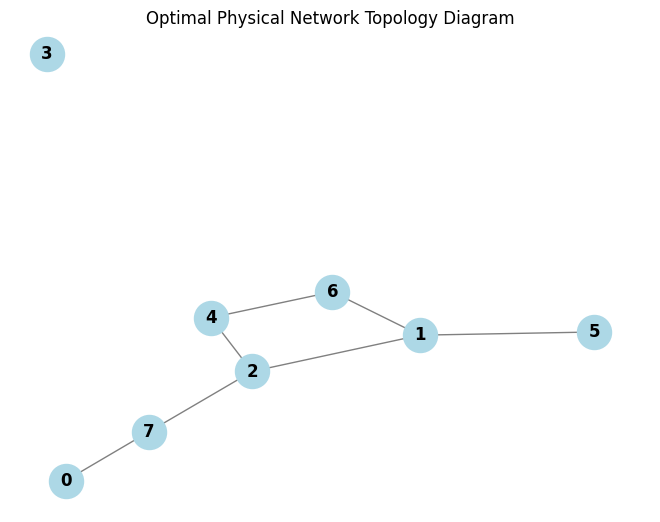

Simulated annealing completed.

Optimal Mapping of Qubits to Nodes:
Qubit 0 -> Node 0
Qubit 1 -> Node 0
Qubit 2 -> Node 1
Qubit 3 -> Node 1
Qubit 4 -> Node 2
Qubit 5 -> Node 2
Qubit 6 -> Node 6
Qubit 7 -> Node 6
Qubit 8 -> Node 7
Qubit 9 -> Node 7
Qubit 10 -> Node 3
Qubit 11 -> Node 3
Qubit 12 -> Node 4
Qubit 13 -> Node 4

Total Communication Cost: 81.8310

Optimal Network Topology:


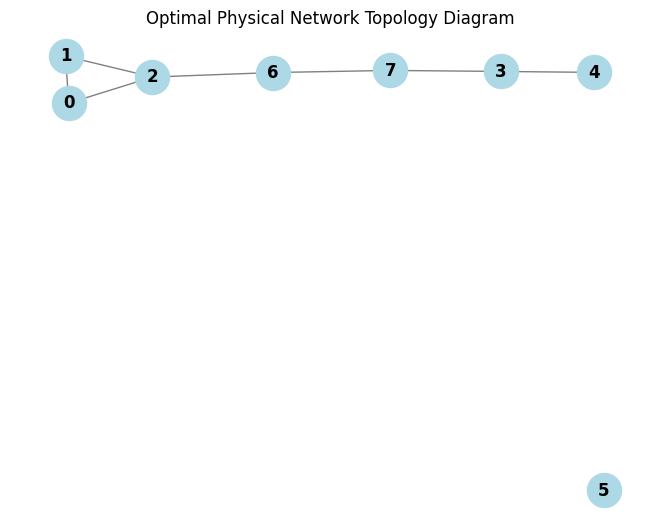

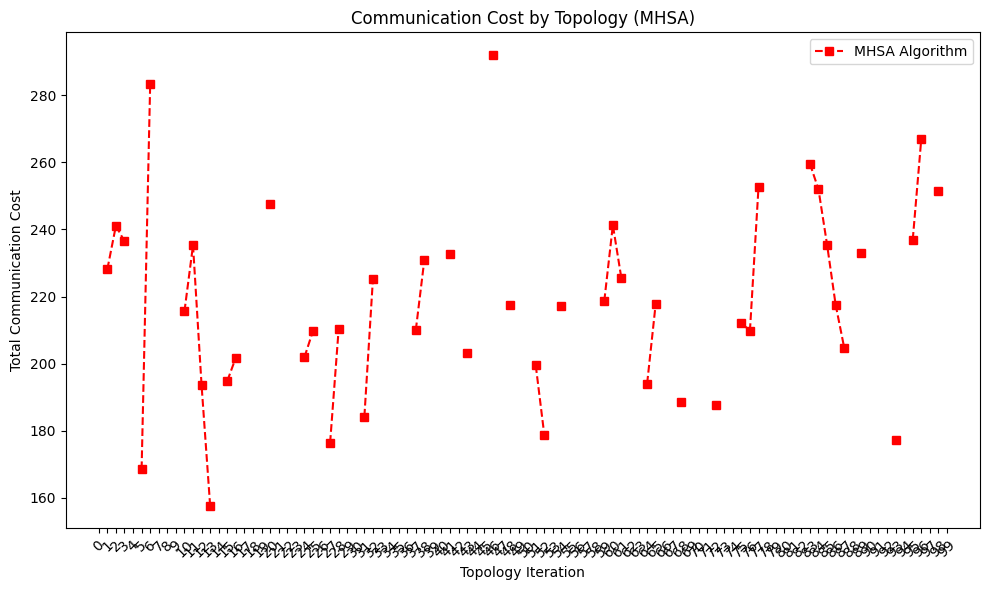

In [ ]:
import random
import math
import networkx as nx
import re
from collections import Counter
import matplotlib.pyplot as plt

# Global parameters

NUM_NODES = 8      # Number of QPU nodes in the network.
NUM_QUBITS = 14    # Number of logical qubits in the quantum circuit.
MAX_EDGES = 7      # Maximum allowed edges in the topology.
PE = 0.99          # Success rate of EPR pair generation.
PS = 0.763         # Success rate of entanglement swapping.
PC = 0.79          # Fidelity of remote CNOT circuit.
nodes_degree = [3 for _ in range(NUM_NODES)]  # Maximum number of edges per node.
# capacity = [2 for _ in range(NUM_NODES)]
# Hyperparameters for DQC-TG(-Plus) algorithm
ALPHA = 0.9        # Cooling parameter for simulated annealing.
N_EQ_LB = 5        # Number of trials for equilibrium test.
N_STUCK = 5        # Conversion point (stuck condition).
N_STAGE = 10       # Number of reheating stages.
N_ITER = 100       # Number of iterations with different initial solutions.


def extract_cnot_operations(qasm_file):
    """
    Extracts CNOT pairs and counts from a given QASM file.
    """
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()
    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]
    return Counter(normalized_pairs)


def random_initial_mapping(capacities):
    """
    Generates a random initial mapping of qubits to nodes based on their capacities.
    """
    available = []
    for node, cap in enumerate(capacities):
        available.extend([node] * cap)
    if len(available) < NUM_QUBITS:
        raise ValueError("Capacity insufficient to map all qubits.")
    random.shuffle(available)
    mapping = available[:NUM_QUBITS]

    network_graph = nx.random_regular_graph(3, NUM_NODES)
    while network_graph.number_of_edges() > MAX_EDGES:
        edge = random.choice(list(network_graph.edges()))
        network_graph.remove_edge(*edge)

    return mapping, network_graph


def node_distance(i, j, network_graph):
    """
    Returns the distance (in hop count) between two nodes i and j
    in the current network topology (network_graph).
    """
    try:
        distance = nx.shortest_path_length(network_graph, source=i, target=j)
    except nx.NetworkXNoPath:
        distance = float('inf')
    return distance


def calculate_cost(mapping, coupled_pairs, network_graph):
    """
    Calculates the total communication cost for a given qubit mapping.
    """
    total_cost = 0.0
    for (q1, q2), cnt in coupled_pairs.items():
        node1 = mapping[q1]
        node2 = mapping[q2]
        if node1 == node2:
            cost = 0
        else:
            d = max(1, node_distance(node1, node2, network_graph))
            denominator = (PE ** d) * (PS ** (d - 1)) * PC
            cost = 1.0 / denominator if denominator != 0 else float('inf')
        total_cost += cost * cnt
    return total_cost


def two_plus_one_move(network_graph):
    """
    Implements the (2+1)-move algorithm as described in Algorithm 1.
    Generates a neighborhood of solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph.

    Parameters:
        network_graph: NetworkX Graph - The current network topology design W.

    Returns:
        neighborhood_solutions: List[NetworkX Graph] - The neighborhood of solutions.
    """
    neighborhood_solutions = []
    edges = list(network_graph.edges())

    # Step 3-10: Conditional pairwise exchange
    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            va, vb = edges[i]
            vc, vd = edges[j]

            # Ensure all nodes are distinct
            if len(set([va, vb, vc, vd])) == 4:
                # Case 1: Replace (va, vb) and (vc, vd) with (va, vc) and (vb, vd)
                if not network_graph.has_edge(va, vc) and not network_graph.has_edge(vb, vd):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vc)
                    new_graph.add_edge(vb, vd)
                    neighborhood_solutions.append(new_graph)

                # Case 2: Replace (va, vb) and (vc, vd) with (va, vd) and (vb, vc)
                if not network_graph.has_edge(va, vd) and not network_graph.has_edge(vb, vc):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vd)
                    new_graph.add_edge(vb, vc)
                    neighborhood_solutions.append(new_graph)

    # Step 11-16: Single-edge spin move
    for i in range(len(edges)):
        va, vb = edges[i]
        for node in network_graph.nodes():
            # Check if node has idle communication qubits (degree < max degree)
            if node != va and node != vb and network_graph.degree[node] < nodes_degree[node]:
                # Case 3
                # Spin edge (va, vb) to (va, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(va, node)
                neighborhood_solutions.append(new_graph)

                # Spin edge (va, vb) to (vb, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(vb, node)
                neighborhood_solutions.append(new_graph)

    return neighborhood_solutions


def two_plus_one_smove(mapping, coupled_pairs, network_graph, capacities):
    """
    Implements the (2+1)-s-move algorithm as described in Algorithm 2.
    Generates neighborhood solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph and adjusts qubit allocation.
    """
    neighborhood_solutions = []

    # Step 1: Generate neighborhood of W using (2+1)-move
    topology_neighborhood = two_plus_one_move(network_graph)

    # Step 2: Add each topology solution with the current mapping into the neighborhood
    for temp_network_graph in topology_neighborhood:
        neighborhood_solutions.append((temp_network_graph, mapping.copy()))

    # Step 3: Adjust mapping to ensure all qubits are allocated properly
    num_qubits = len(mapping)
    num_nodes = len(capacities)
    total_capacity = sum(capacities)

    if num_qubits < total_capacity:
        # Add pseudo logical qubits to fill unused computation capacity
        extended_mapping = mapping + [None] * (total_capacity - num_qubits)
        mapping = extended_mapping

    # Iterate over nodes and ensure capacity constraints are satisfied
    for node in range(num_nodes):
        while sum(1 for q in mapping if q == node) < capacities[node]:
            # Find a pseudo qubit and allocate it to this node
            for i in range(len(mapping)):
                if mapping[i] is None:
                    mapping[i] = node
                    break

    # Step 4: Perform qubit swaps between real logical qubits or pseudo logical qubits
    for i in range(len(mapping)):
        for j in range(i + 1, len(mapping)):
            if mapping[i] != mapping[j]:
                # Generate new mapping by swapping qubits i and j
                new_mapping = mapping.copy()
                new_mapping[i], new_mapping[j] = new_mapping[j], new_mapping[i]

                # Ensure only real logical qubits are swapped back into the original size
                trimmed_mapping = new_mapping[:num_qubits]

                # Add the new solution (network topology + qubit allocation) to the neighborhood
                neighborhood_solutions.append((network_graph.copy(), trimmed_mapping))

    return neighborhood_solutions

def simulated_annealing(coupled_pairs, initial_mapping, initial_network, capacities, t0=10):
    """
    Implements the Simulated Annealing (SA) algorithm with reheating and iterated mechanism.

    Parameters:
        coupled_pairs: Counter - CNOT operations extracted from the quantum circuit.
        initial_mapping: List - Initial mapping of qubits to nodes.
        initial_network: NetworkX Graph - Initial network topology.
        capacities: List - Capacity of each QPU node.
        t0: float - Initial temperature for SA.

    Returns:
        best_mapping: List - Optimal qubit-to-node mapping.
        best_network: NetworkX Graph - Optimal network topology.
        best_cost: float - Minimum communication cost achieved.
    """
    best_mapping = None
    best_network = None
    best_cost = float('inf')
    costs=[]  # Initialize with a very high cost

    # Iterated mechanism: Perform SA for N_ITER iterations with different initial solutions
    for iteration in range(N_ITER):
        # print(f"Iteration {iteration + 1}/{N_ITER}: Starting simulated annealing...")

        # Generate random initial solution for this iteration
        current_mapping, current_network = random_initial_mapping(capacities)
        current_cost = calculate_cost(current_mapping, coupled_pairs, current_network)
        costs.append(current_cost)

        temperature = t0
        stuck_count = 0  # Count how long we've been stuck without improvement

        # Multistage reheating mechanism (N_STAGE stages)
        for stage in range(N_STAGE):
            # print(f"Stage {stage + 1}/{N_STAGE}: Starting with temperature {temperature:.2f}")

            for _ in range(N_EQ_LB):  # Equilibrium test
                # Generate neighborhood solutions using (2+1)-s-move
                neighbors = two_plus_one_smove(current_mapping, coupled_pairs, current_network, capacities)

                for neighbor_network, neighbor_mapping in neighbors:
                    # Calculate cost for the neighbor solution
                    neighbor_cost = calculate_cost(neighbor_mapping, coupled_pairs, neighbor_network)

                    # Determine acceptance probability
                    delta_cost = neighbor_cost - current_cost
                    if delta_cost < 0 or random.random() < math.exp(-delta_cost / temperature):
                        # Accept the neighbor solution
                        current_mapping = neighbor_mapping[:]
                        current_network = neighbor_network.copy()
                        current_cost = neighbor_cost
                        # costs.append(current_cost)

                        # Update best solution if improved
                        if current_cost < best_cost:
                            best_mapping = current_mapping[:]
                            best_network = current_network.copy()
                            best_cost = current_cost
                            stuck_count = 0  # Reset stuck counter after improvement
                        else:
                            stuck_count += 1

                # Check if stuck condition is met
                if stuck_count >= N_STUCK:
                    # print(f"Stuck at local optimum. Switching to local search...")
                    # Perform local search using (2+1)-opt to escape local optima
                    neighbors = two_plus_one_move(current_network)
                    for neighbor in neighbors:
                        temp_cost = calculate_cost(current_mapping, coupled_pairs, neighbor)
                        if temp_cost < current_cost:
                            current_network = neighbor.copy()
                            current_cost = temp_cost
                            # costs.append(current_cost)
                            break

            # Reduce temperature (cooling schedule)
            temperature *= ALPHA

            # Reheat if necessary (multistage reheating mechanism)
            if stage < N_STAGE - 1:
                temperature = t0

            # print(f"Stage {stage + 1} completed. Best cost so far: {best_cost:.4f}")

    print("Simulated annealing completed.")
    return best_mapping, best_network, best_cost,costs

def draw_topology(network_graph):
    """
    Draws the physical network topology diagram using networkx and matplotlib.
    (This diagram shows the original network_graph.)
    """
    pos = nx.spring_layout(network_graph)
    nx.draw(network_graph, pos, with_labels=True, node_color="lightblue",
            edge_color="gray", node_size=600, font_weight="bold")
    plt.title("Optimal Physical Network Topology Diagram")
    plt.show()

# Main function to execute the algorithm
def main(qasm_file):
    """
    Main function to execute the entire DQC-TG framework using Simulated Annealing.

    Parameters:
        qasm_file: str - Path to the QASM file containing the quantum circuit.
    """
    capacities = [2] * NUM_NODES  # Example capacities for each QPU node

    # Extract CNOT operations from QASM file
    coupled_pairs = extract_cnot_operations(qasm_file)

    # Generate initial random mapping and network topology
    initial_mapping, initial_network = random_initial_mapping(capacities)

    print("Initial Mapping:", initial_mapping)
    print("Initial Network Topology:")
    draw_topology(initial_network)

    # Run simulated annealing to optimize topology and mapping
    best_mapping, best_network, best_cost,costs = simulated_annealing(
        coupled_pairs,
        initial_mapping,
        initial_network,
        capacities,
        t0=10  # Initial temperature
    )

    print("\nOptimal Mapping of Qubits to Nodes:")
    for qubit, node in enumerate(best_mapping):
        print(f"Qubit {qubit} -> Node {node}")

    print(f"\nTotal Communication Cost: {best_cost:.4f}")

    print("\nOptimal Network Topology:")
    draw_topology(best_network)
    plt.figure(figsize=(10, 6))
    x = list(range(len(costs)))
    plt.plot(x, costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.xticks(x,x, rotation=45)
    plt.xlabel("Topology Iteration")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Execute main function with a sample QASM file path
if __name__ == "__main__":
    qasm_file_path = "/content/0410184_169.qasm"  # Replace with your actual file path
    main(qasm_file_path)

410184 C=9

Initial Mapping: [7, 2, 6, 6, 1, 5, 4, 0, 7, 3, 3, 0, 4, 2]
Initial Network Topology:


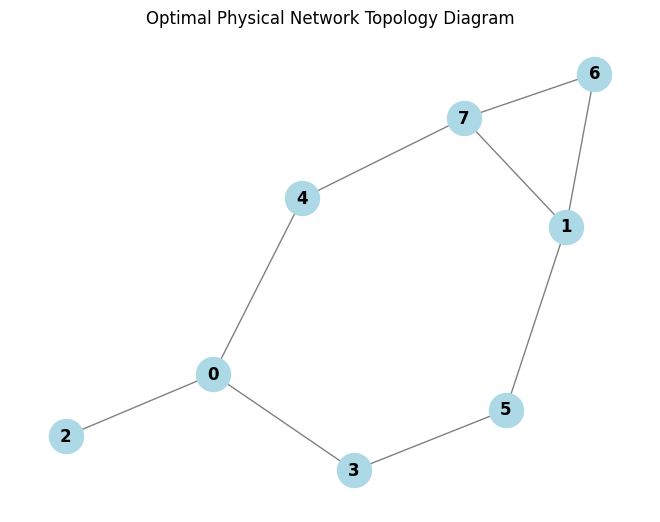

Simulated annealing completed.

Optimal Mapping of Qubits to Nodes:
Qubit 0 -> Node 5
Qubit 1 -> Node 5
Qubit 2 -> Node 3
Qubit 3 -> Node 2
Qubit 4 -> Node 3
Qubit 5 -> Node 1
Qubit 6 -> Node 1
Qubit 7 -> Node 6
Qubit 8 -> Node 6
Qubit 9 -> Node 0
Qubit 10 -> Node 0
Qubit 11 -> Node 7
Qubit 12 -> Node 4
Qubit 13 -> Node 7

Total Communication Cost: 90.7812

Optimal Network Topology:


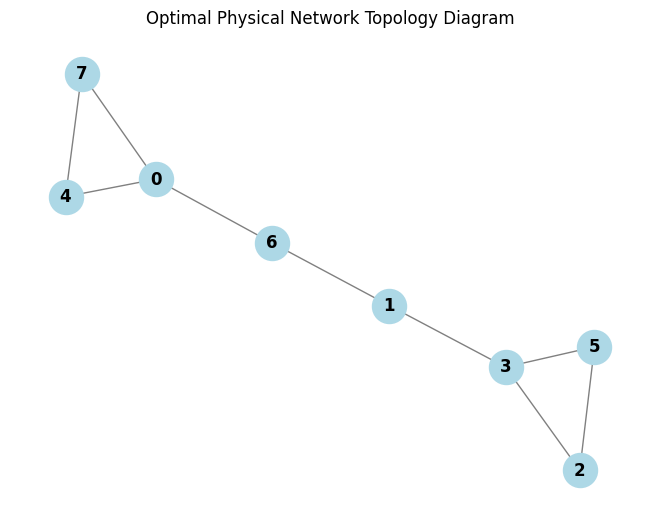

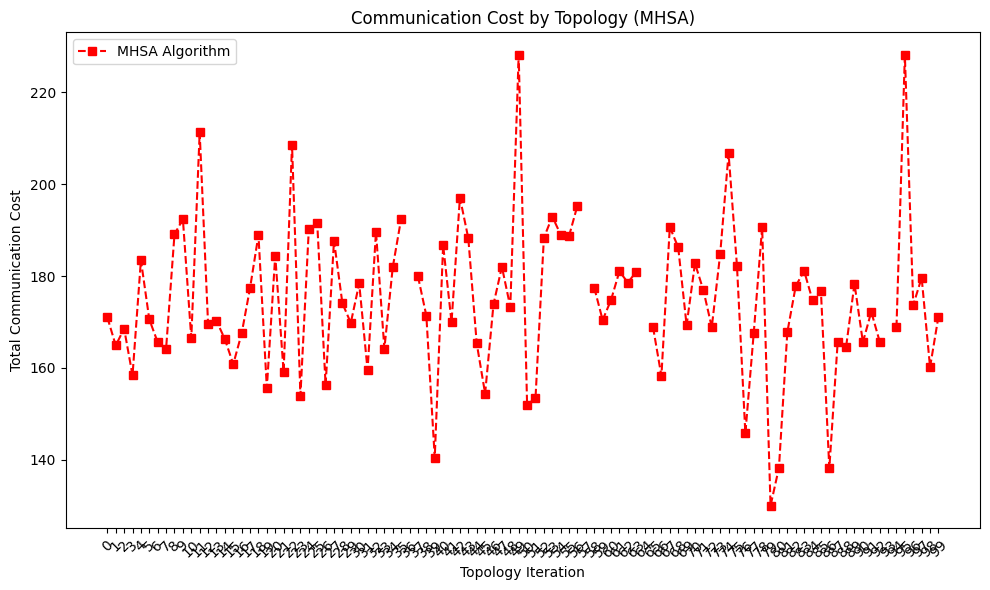

In [ ]:
import random
import math
import networkx as nx
import re
from collections import Counter
import matplotlib.pyplot as plt

# Global parameters

NUM_NODES = 8      # Number of QPU nodes in the network.
NUM_QUBITS = 14    # Number of logical qubits in the quantum circuit.
MAX_EDGES = 9      # Maximum allowed edges in the topology.
PE = 0.99          # Success rate of EPR pair generation.
PS = 0.763         # Success rate of entanglement swapping.
PC = 0.79          # Fidelity of remote CNOT circuit.
nodes_degree = [3 for _ in range(NUM_NODES)]  # Maximum number of edges per node.
# capacity = [2 for _ in range(NUM_NODES)]
# Hyperparameters for DQC-TG(-Plus) algorithm
ALPHA = 0.9        # Cooling parameter for simulated annealing.
N_EQ_LB = 5        # Number of trials for equilibrium test.
N_STUCK = 5        # Conversion point (stuck condition).
N_STAGE = 10       # Number of reheating stages.
N_ITER = 100       # Number of iterations with different initial solutions.


def extract_cnot_operations(qasm_file):
    """
    Extracts CNOT pairs and counts from a given QASM file.
    """
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()
    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]
    return Counter(normalized_pairs)


def random_initial_mapping(capacities):
    """
    Generates a random initial mapping of qubits to nodes based on their capacities.
    """
    available = []
    for node, cap in enumerate(capacities):
        available.extend([node] * cap)
    if len(available) < NUM_QUBITS:
        raise ValueError("Capacity insufficient to map all qubits.")
    random.shuffle(available)
    mapping = available[:NUM_QUBITS]

    network_graph = nx.random_regular_graph(3, NUM_NODES)
    while network_graph.number_of_edges() > MAX_EDGES:
        edge = random.choice(list(network_graph.edges()))
        network_graph.remove_edge(*edge)

    return mapping, network_graph


def node_distance(i, j, network_graph):
    """
    Returns the distance (in hop count) between two nodes i and j
    in the current network topology (network_graph).
    """
    try:
        distance = nx.shortest_path_length(network_graph, source=i, target=j)
    except nx.NetworkXNoPath:
        distance = float('inf')
    return distance


def calculate_cost(mapping, coupled_pairs, network_graph):
    """
    Calculates the total communication cost for a given qubit mapping.
    """
    total_cost = 0.0
    for (q1, q2), cnt in coupled_pairs.items():
        node1 = mapping[q1]
        node2 = mapping[q2]
        if node1 == node2:
            cost = 0
        else:
            d = max(1, node_distance(node1, node2, network_graph))
            denominator = (PE ** d) * (PS ** (d - 1)) * PC
            cost = 1.0 / denominator if denominator != 0 else float('inf')
        total_cost += cost * cnt
    return total_cost


def two_plus_one_move(network_graph):
    """
    Implements the (2+1)-move algorithm as described in Algorithm 1.
    Generates a neighborhood of solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph.

    Parameters:
        network_graph: NetworkX Graph - The current network topology design W.

    Returns:
        neighborhood_solutions: List[NetworkX Graph] - The neighborhood of solutions.
    """
    neighborhood_solutions = []
    edges = list(network_graph.edges())

    # Step 3-10: Conditional pairwise exchange
    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            va, vb = edges[i]
            vc, vd = edges[j]

            # Ensure all nodes are distinct
            if len(set([va, vb, vc, vd])) == 4:
                # Case 1: Replace (va, vb) and (vc, vd) with (va, vc) and (vb, vd)
                if not network_graph.has_edge(va, vc) and not network_graph.has_edge(vb, vd):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vc)
                    new_graph.add_edge(vb, vd)
                    neighborhood_solutions.append(new_graph)

                # Case 2: Replace (va, vb) and (vc, vd) with (va, vd) and (vb, vc)
                if not network_graph.has_edge(va, vd) and not network_graph.has_edge(vb, vc):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vd)
                    new_graph.add_edge(vb, vc)
                    neighborhood_solutions.append(new_graph)

    # Step 11-16: Single-edge spin move
    for i in range(len(edges)):
        va, vb = edges[i]
        for node in network_graph.nodes():
            # Check if node has idle communication qubits (degree < max degree)
            if node != va and node != vb and network_graph.degree[node] < nodes_degree[node]:
                # Case 3
                # Spin edge (va, vb) to (va, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(va, node)
                neighborhood_solutions.append(new_graph)

                # Spin edge (va, vb) to (vb, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(vb, node)
                neighborhood_solutions.append(new_graph)

    return neighborhood_solutions


def two_plus_one_smove(mapping, coupled_pairs, network_graph, capacities):
    """
    Implements the (2+1)-s-move algorithm as described in Algorithm 2.
    Generates neighborhood solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph and adjusts qubit allocation.
    """
    neighborhood_solutions = []

    # Step 1: Generate neighborhood of W using (2+1)-move
    topology_neighborhood = two_plus_one_move(network_graph)

    # Step 2: Add each topology solution with the current mapping into the neighborhood
    for temp_network_graph in topology_neighborhood:
        neighborhood_solutions.append((temp_network_graph, mapping.copy()))

    # Step 3: Adjust mapping to ensure all qubits are allocated properly
    num_qubits = len(mapping)
    num_nodes = len(capacities)
    total_capacity = sum(capacities)

    if num_qubits < total_capacity:
        # Add pseudo logical qubits to fill unused computation capacity
        extended_mapping = mapping + [None] * (total_capacity - num_qubits)
        mapping = extended_mapping

    # Iterate over nodes and ensure capacity constraints are satisfied
    for node in range(num_nodes):
        while sum(1 for q in mapping if q == node) < capacities[node]:
            # Find a pseudo qubit and allocate it to this node
            for i in range(len(mapping)):
                if mapping[i] is None:
                    mapping[i] = node
                    break

    # Step 4: Perform qubit swaps between real logical qubits or pseudo logical qubits
    for i in range(len(mapping)):
        for j in range(i + 1, len(mapping)):
            if mapping[i] != mapping[j]:
                # Generate new mapping by swapping qubits i and j
                new_mapping = mapping.copy()
                new_mapping[i], new_mapping[j] = new_mapping[j], new_mapping[i]

                # Ensure only real logical qubits are swapped back into the original size
                trimmed_mapping = new_mapping[:num_qubits]

                # Add the new solution (network topology + qubit allocation) to the neighborhood
                neighborhood_solutions.append((network_graph.copy(), trimmed_mapping))

    return neighborhood_solutions

def simulated_annealing(coupled_pairs, initial_mapping, initial_network, capacities, t0=10):
    """
    Implements the Simulated Annealing (SA) algorithm with reheating and iterated mechanism.

    Parameters:
        coupled_pairs: Counter - CNOT operations extracted from the quantum circuit.
        initial_mapping: List - Initial mapping of qubits to nodes.
        initial_network: NetworkX Graph - Initial network topology.
        capacities: List - Capacity of each QPU node.
        t0: float - Initial temperature for SA.

    Returns:
        best_mapping: List - Optimal qubit-to-node mapping.
        best_network: NetworkX Graph - Optimal network topology.
        best_cost: float - Minimum communication cost achieved.
    """
    best_mapping = None
    best_network = None
    best_cost = float('inf')
    costs=[]  # Initialize with a very high cost

    # Iterated mechanism: Perform SA for N_ITER iterations with different initial solutions
    for iteration in range(N_ITER):
        # print(f"Iteration {iteration + 1}/{N_ITER}: Starting simulated annealing...")

        # Generate random initial solution for this iteration
        current_mapping, current_network = random_initial_mapping(capacities)
        current_cost = calculate_cost(current_mapping, coupled_pairs, current_network)
        costs.append(current_cost)

        temperature = t0
        stuck_count = 0  # Count how long we've been stuck without improvement

        # Multistage reheating mechanism (N_STAGE stages)
        for stage in range(N_STAGE):
            # print(f"Stage {stage + 1}/{N_STAGE}: Starting with temperature {temperature:.2f}")

            for _ in range(N_EQ_LB):  # Equilibrium test
                # Generate neighborhood solutions using (2+1)-s-move
                neighbors = two_plus_one_smove(current_mapping, coupled_pairs, current_network, capacities)

                for neighbor_network, neighbor_mapping in neighbors:
                    # Calculate cost for the neighbor solution
                    neighbor_cost = calculate_cost(neighbor_mapping, coupled_pairs, neighbor_network)

                    # Determine acceptance probability
                    delta_cost = neighbor_cost - current_cost
                    if delta_cost < 0 or random.random() < math.exp(-delta_cost / temperature):
                        # Accept the neighbor solution
                        current_mapping = neighbor_mapping[:]
                        current_network = neighbor_network.copy()
                        current_cost = neighbor_cost
                        # costs.append(current_cost)

                        # Update best solution if improved
                        if current_cost < best_cost:
                            best_mapping = current_mapping[:]
                            best_network = current_network.copy()
                            best_cost = current_cost
                            stuck_count = 0  # Reset stuck counter after improvement
                        else:
                            stuck_count += 1

                # Check if stuck condition is met
                if stuck_count >= N_STUCK:
                    # print(f"Stuck at local optimum. Switching to local search...")
                    # Perform local search using (2+1)-opt to escape local optima
                    neighbors = two_plus_one_move(current_network)
                    for neighbor in neighbors:
                        temp_cost = calculate_cost(current_mapping, coupled_pairs, neighbor)
                        if temp_cost < current_cost:
                            current_network = neighbor.copy()
                            current_cost = temp_cost
                            # costs.append(current_cost)
                            break

            # Reduce temperature (cooling schedule)
            temperature *= ALPHA

            # Reheat if necessary (multistage reheating mechanism)
            if stage < N_STAGE - 1:
                temperature = t0

            # print(f"Stage {stage + 1} completed. Best cost so far: {best_cost:.4f}")

    print("Simulated annealing completed.")
    return best_mapping, best_network, best_cost,costs

def draw_topology(network_graph):
    """
    Draws the physical network topology diagram using networkx and matplotlib.
    (This diagram shows the original network_graph.)
    """
    pos = nx.spring_layout(network_graph)
    nx.draw(network_graph, pos, with_labels=True, node_color="lightblue",
            edge_color="gray", node_size=600, font_weight="bold")
    plt.title("Optimal Physical Network Topology Diagram")
    plt.show()

# Main function to execute the algorithm
def main(qasm_file):
    """
    Main function to execute the entire DQC-TG framework using Simulated Annealing.

    Parameters:
        qasm_file: str - Path to the QASM file containing the quantum circuit.
    """
    capacities = [2] * NUM_NODES  # Example capacities for each QPU node

    # Extract CNOT operations from QASM file
    coupled_pairs = extract_cnot_operations(qasm_file)

    # Generate initial random mapping and network topology
    initial_mapping, initial_network = random_initial_mapping(capacities)

    print("Initial Mapping:", initial_mapping)
    print("Initial Network Topology:")
    draw_topology(initial_network)

    # Run simulated annealing to optimize topology and mapping
    best_mapping, best_network, best_cost,costs = simulated_annealing(
        coupled_pairs,
        initial_mapping,
        initial_network,
        capacities,
        t0=10  # Initial temperature
    )

    print("\nOptimal Mapping of Qubits to Nodes:")
    for qubit, node in enumerate(best_mapping):
        print(f"Qubit {qubit} -> Node {node}")

    print(f"\nTotal Communication Cost: {best_cost:.4f}")

    print("\nOptimal Network Topology:")
    draw_topology(best_network)
    plt.figure(figsize=(10, 6))
    x = list(range(len(costs)))
    plt.plot(x, costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.xticks(x,x, rotation=45)
    plt.xlabel("Topology Iteration")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Execute main function with a sample QASM file path
if __name__ == "__main__":
    qasm_file_path = "/content/0410184_169.qasm"  # Replace with your actual file path
    main(qasm_file_path)

adr4

Initial Mapping: [5, 1, 0, 4, 6, 4, 3, 5, 7, 3, 7, 2, 6, 1]
Initial Network Topology:


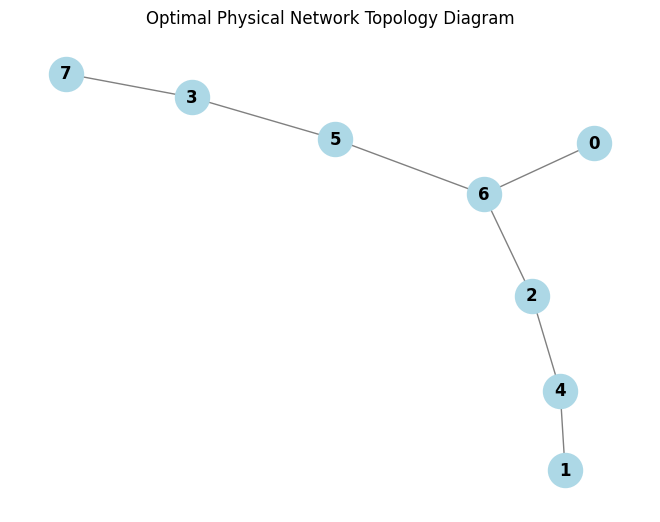

Simulated annealing completed.

Optimal Mapping of Qubits to Nodes:
Qubit 0 -> Node 4
Qubit 1 -> Node 1
Qubit 2 -> Node 1
Qubit 3 -> Node 6
Qubit 4 -> Node 5
Qubit 5 -> Node 6
Qubit 6 -> Node 2
Qubit 7 -> Node 3
Qubit 8 -> Node 7
Qubit 9 -> Node 7
Qubit 10 -> Node 2
Qubit 11 -> Node 3
Qubit 12 -> Node 5
Qubit 13 -> Node 0

Total Communication Cost: 1709.8490

Optimal Network Topology:


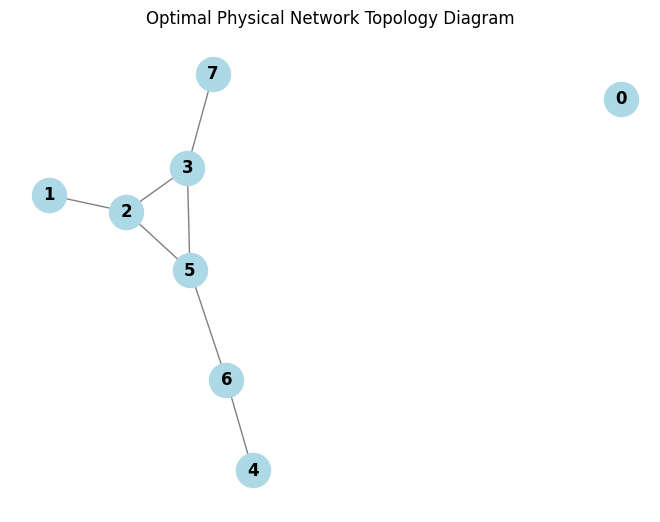

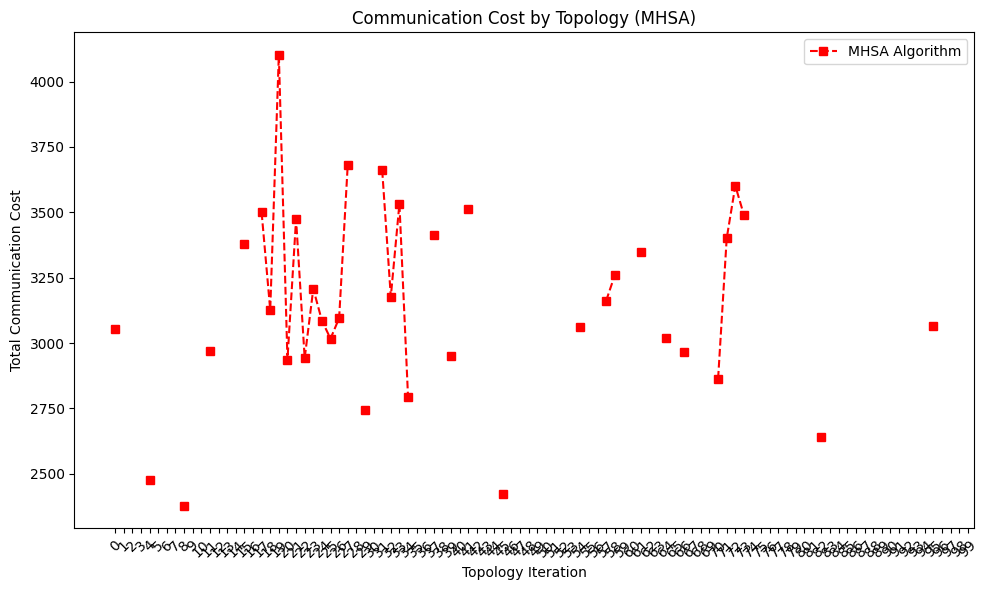

In [ ]:
import random
import math
import networkx as nx
import re
from collections import Counter
import matplotlib.pyplot as plt

# Global parameters

NUM_NODES = 8      # Number of QPU nodes in the network.
NUM_QUBITS = 14    # Number of logical qubits in the quantum circuit.
MAX_EDGES = 7      # Maximum allowed edges in the topology.
PE = 0.99          # Success rate of EPR pair generation.
PS = 0.763         # Success rate of entanglement swapping.
PC = 0.79          # Fidelity of remote CNOT circuit.
nodes_degree = [3 for _ in range(NUM_NODES)]  # Maximum number of edges per node.
# capacity = [2 for _ in range(NUM_NODES)]
# Hyperparameters for DQC-TG(-Plus) algorithm
ALPHA = 0.9        # Cooling parameter for simulated annealing.
N_EQ_LB = 5        # Number of trials for equilibrium test.
N_STUCK = 5        # Conversion point (stuck condition).
N_STAGE = 10       # Number of reheating stages.
N_ITER = 100       # Number of iterations with different initial solutions.


def extract_cnot_operations(qasm_file):
    """
    Extracts CNOT pairs and counts from a given QASM file.
    """
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()
    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]
    return Counter(normalized_pairs)


def random_initial_mapping(capacities):
    """
    Generates a random initial mapping of qubits to nodes based on their capacities.
    """
    available = []
    for node, cap in enumerate(capacities):
        available.extend([node] * cap)
    if len(available) < NUM_QUBITS:
        raise ValueError("Capacity insufficient to map all qubits.")
    random.shuffle(available)
    mapping = available[:NUM_QUBITS]

    network_graph = nx.random_regular_graph(3, NUM_NODES)
    while network_graph.number_of_edges() > MAX_EDGES:
        edge = random.choice(list(network_graph.edges()))
        network_graph.remove_edge(*edge)

    return mapping, network_graph


def node_distance(i, j, network_graph):
    """
    Returns the distance (in hop count) between two nodes i and j
    in the current network topology (network_graph).
    """
    try:
        distance = nx.shortest_path_length(network_graph, source=i, target=j)
    except nx.NetworkXNoPath:
        distance = float('inf')
    return distance


def calculate_cost(mapping, coupled_pairs, network_graph):
    """
    Calculates the total communication cost for a given qubit mapping.
    """
    total_cost = 0.0
    for (q1, q2), cnt in coupled_pairs.items():
        node1 = mapping[q1]
        node2 = mapping[q2]
        if node1 == node2:
            cost = 0
        else:
            d = max(1, node_distance(node1, node2, network_graph))
            denominator = (PE ** d) * (PS ** (d - 1)) * PC
            cost = 1.0 / denominator if denominator != 0 else float('inf')
        total_cost += cost * cnt
    return total_cost


def two_plus_one_move(network_graph):
    """
    Implements the (2+1)-move algorithm as described in Algorithm 1.
    Generates a neighborhood of solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph.

    Parameters:
        network_graph: NetworkX Graph - The current network topology design W.

    Returns:
        neighborhood_solutions: List[NetworkX Graph] - The neighborhood of solutions.
    """
    neighborhood_solutions = []
    edges = list(network_graph.edges())

    # Step 3-10: Conditional pairwise exchange
    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            va, vb = edges[i]
            vc, vd = edges[j]

            # Ensure all nodes are distinct
            if len(set([va, vb, vc, vd])) == 4:
                # Case 1: Replace (va, vb) and (vc, vd) with (va, vc) and (vb, vd)
                if not network_graph.has_edge(va, vc) and not network_graph.has_edge(vb, vd):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vc)
                    new_graph.add_edge(vb, vd)
                    neighborhood_solutions.append(new_graph)

                # Case 2: Replace (va, vb) and (vc, vd) with (va, vd) and (vb, vc)
                if not network_graph.has_edge(va, vd) and not network_graph.has_edge(vb, vc):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vd)
                    new_graph.add_edge(vb, vc)
                    neighborhood_solutions.append(new_graph)

    # Step 11-16: Single-edge spin move
    for i in range(len(edges)):
        va, vb = edges[i]
        for node in network_graph.nodes():
            # Check if node has idle communication qubits (degree < max degree)
            if node != va and node != vb and network_graph.degree[node] < nodes_degree[node]:
                # Case 3
                # Spin edge (va, vb) to (va, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(va, node)
                neighborhood_solutions.append(new_graph)

                # Spin edge (va, vb) to (vb, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(vb, node)
                neighborhood_solutions.append(new_graph)

    return neighborhood_solutions


def two_plus_one_smove(mapping, coupled_pairs, network_graph, capacities):
    """
    Implements the (2+1)-s-move algorithm as described in Algorithm 2.
    Generates neighborhood solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph and adjusts qubit allocation.
    """
    neighborhood_solutions = []

    # Step 1: Generate neighborhood of W using (2+1)-move
    topology_neighborhood = two_plus_one_move(network_graph)

    # Step 2: Add each topology solution with the current mapping into the neighborhood
    for temp_network_graph in topology_neighborhood:
        neighborhood_solutions.append((temp_network_graph, mapping.copy()))

    # Step 3: Adjust mapping to ensure all qubits are allocated properly
    num_qubits = len(mapping)
    num_nodes = len(capacities)
    total_capacity = sum(capacities)

    if num_qubits < total_capacity:
        # Add pseudo logical qubits to fill unused computation capacity
        extended_mapping = mapping + [None] * (total_capacity - num_qubits)
        mapping = extended_mapping

    # Iterate over nodes and ensure capacity constraints are satisfied
    for node in range(num_nodes):
        while sum(1 for q in mapping if q == node) < capacities[node]:
            # Find a pseudo qubit and allocate it to this node
            for i in range(len(mapping)):
                if mapping[i] is None:
                    mapping[i] = node
                    break

    # Step 4: Perform qubit swaps between real logical qubits or pseudo logical qubits
    for i in range(len(mapping)):
        for j in range(i + 1, len(mapping)):
            if mapping[i] != mapping[j]:
                # Generate new mapping by swapping qubits i and j
                new_mapping = mapping.copy()
                new_mapping[i], new_mapping[j] = new_mapping[j], new_mapping[i]

                # Ensure only real logical qubits are swapped back into the original size
                trimmed_mapping = new_mapping[:num_qubits]

                # Add the new solution (network topology + qubit allocation) to the neighborhood
                neighborhood_solutions.append((network_graph.copy(), trimmed_mapping))

    return neighborhood_solutions

def simulated_annealing(coupled_pairs, initial_mapping, initial_network, capacities, t0=10):
    """
    Implements the Simulated Annealing (SA) algorithm with reheating and iterated mechanism.

    Parameters:
        coupled_pairs: Counter - CNOT operations extracted from the quantum circuit.
        initial_mapping: List - Initial mapping of qubits to nodes.
        initial_network: NetworkX Graph - Initial network topology.
        capacities: List - Capacity of each QPU node.
        t0: float - Initial temperature for SA.

    Returns:
        best_mapping: List - Optimal qubit-to-node mapping.
        best_network: NetworkX Graph - Optimal network topology.
        best_cost: float - Minimum communication cost achieved.
    """
    best_mapping = None
    best_network = None
    best_cost = float('inf')
    costs=[]  # Initialize with a very high cost

    # Iterated mechanism: Perform SA for N_ITER iterations with different initial solutions
    for iteration in range(N_ITER):
        # print(f"Iteration {iteration + 1}/{N_ITER}: Starting simulated annealing...")

        # Generate random initial solution for this iteration
        current_mapping, current_network = random_initial_mapping(capacities)
        current_cost = calculate_cost(current_mapping, coupled_pairs, current_network)
        costs.append(current_cost)

        temperature = t0
        stuck_count = 0  # Count how long we've been stuck without improvement

        # Multistage reheating mechanism (N_STAGE stages)
        for stage in range(N_STAGE):
            # print(f"Stage {stage + 1}/{N_STAGE}: Starting with temperature {temperature:.2f}")

            for _ in range(N_EQ_LB):  # Equilibrium test
                # Generate neighborhood solutions using (2+1)-s-move
                neighbors = two_plus_one_smove(current_mapping, coupled_pairs, current_network, capacities)

                for neighbor_network, neighbor_mapping in neighbors:
                    # Calculate cost for the neighbor solution
                    neighbor_cost = calculate_cost(neighbor_mapping, coupled_pairs, neighbor_network)

                    # Determine acceptance probability
                    delta_cost = neighbor_cost - current_cost
                    if delta_cost < 0 or random.random() < math.exp(-delta_cost / temperature):
                        # Accept the neighbor solution
                        current_mapping = neighbor_mapping[:]
                        current_network = neighbor_network.copy()
                        current_cost = neighbor_cost
                        # costs.append(current_cost)

                        # Update best solution if improved
                        if current_cost < best_cost:
                            best_mapping = current_mapping[:]
                            best_network = current_network.copy()
                            best_cost = current_cost
                            stuck_count = 0  # Reset stuck counter after improvement
                        else:
                            stuck_count += 1

                # Check if stuck condition is met
                if stuck_count >= N_STUCK:
                    # print(f"Stuck at local optimum. Switching to local search...")
                    # Perform local search using (2+1)-opt to escape local optima
                    neighbors = two_plus_one_move(current_network)
                    for neighbor in neighbors:
                        temp_cost = calculate_cost(current_mapping, coupled_pairs, neighbor)
                        if temp_cost < current_cost:
                            current_network = neighbor.copy()
                            current_cost = temp_cost
                            # costs.append(current_cost)
                            break

            # Reduce temperature (cooling schedule)
            temperature *= ALPHA

            # Reheat if necessary (multistage reheating mechanism)
            if stage < N_STAGE - 1:
                temperature = t0

            # print(f"Stage {stage + 1} completed. Best cost so far: {best_cost:.4f}")

    print("Simulated annealing completed.")
    return best_mapping, best_network, best_cost,costs

def draw_topology(network_graph):
    """
    Draws the physical network topology diagram using networkx and matplotlib.
    (This diagram shows the original network_graph.)
    """
    pos = nx.spring_layout(network_graph)
    nx.draw(network_graph, pos, with_labels=True, node_color="lightblue",
            edge_color="gray", node_size=600, font_weight="bold")
    plt.title("Optimal Physical Network Topology Diagram")
    plt.show()

# Main function to execute the algorithm
def main(qasm_file):
    """
    Main function to execute the entire DQC-TG framework using Simulated Annealing.

    Parameters:
        qasm_file: str - Path to the QASM file containing the quantum circuit.
    """
    capacities = [2] * NUM_NODES  # Example capacities for each QPU node

    # Extract CNOT operations from QASM file
    coupled_pairs = extract_cnot_operations(qasm_file)

    # Generate initial random mapping and network topology
    initial_mapping, initial_network = random_initial_mapping(capacities)

    print("Initial Mapping:", initial_mapping)
    print("Initial Network Topology:")
    draw_topology(initial_network)

    # Run simulated annealing to optimize topology and mapping
    best_mapping, best_network, best_cost,costs = simulated_annealing(
        coupled_pairs,
        initial_mapping,
        initial_network,
        capacities,
        t0=10  # Initial temperature
    )

    print("\nOptimal Mapping of Qubits to Nodes:")
    for qubit, node in enumerate(best_mapping):
        print(f"Qubit {qubit} -> Node {node}")

    print(f"\nTotal Communication Cost: {best_cost:.4f}")

    print("\nOptimal Network Topology:")
    draw_topology(best_network)
    plt.figure(figsize=(10, 6))
    x = list(range(len(costs)))
    plt.plot(x, costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.xticks(x,x, rotation=45)
    plt.xlabel("Topology Iteration")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Execute main function with a sample QASM file path
if __name__ == "__main__":
    qasm_file_path = "/content/adr4_197.qasm"  # Replace with your actual file path
    main(qasm_file_path)

Initial Mapping: [3, 1, 5, 6, 4, 0, 2, 2, 7, 5, 7, 1, 6, 0]
Initial Network Topology:


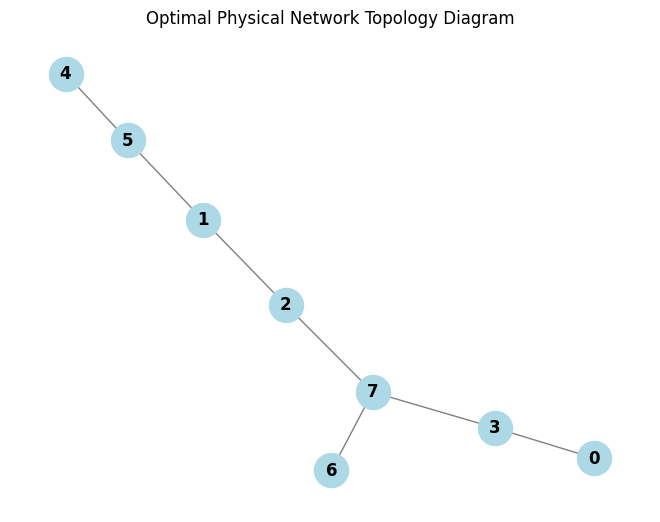

Simulated annealing completed.

Optimal Mapping of Qubits to Nodes:
Qubit 0 -> Node 3
Qubit 1 -> Node 3
Qubit 2 -> Node 4
Qubit 3 -> Node 4
Qubit 4 -> Node 5
Qubit 5 -> Node 2
Qubit 6 -> Node 1
Qubit 7 -> Node 0
Qubit 8 -> Node 7
Qubit 9 -> Node 7
Qubit 10 -> Node 5
Qubit 11 -> Node 0
Qubit 12 -> Node 1
Qubit 13 -> Node 2

Total Communication Cost: 18410.2899

Optimal Network Topology:


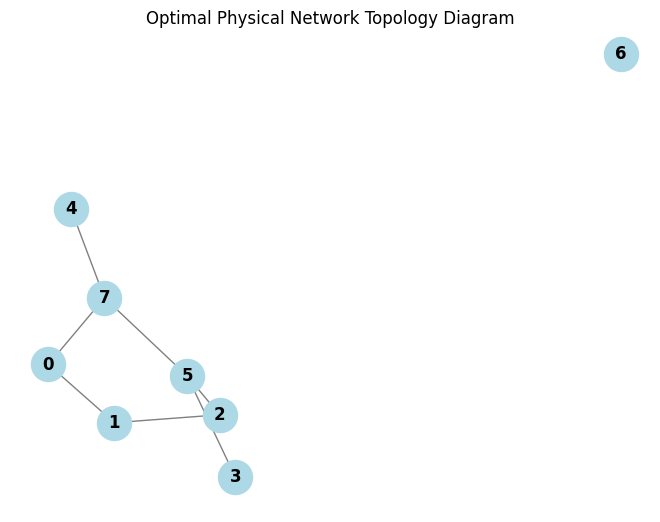

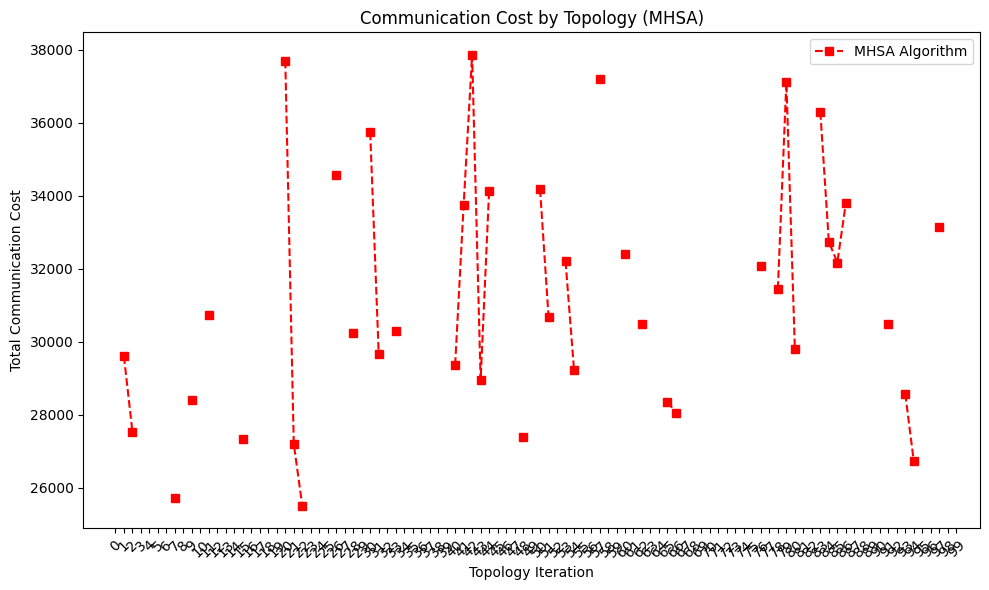

In [ ]:
import random
import math
import networkx as nx
import re
from collections import Counter
import matplotlib.pyplot as plt

# Global parameters

NUM_NODES = 8      # Number of QPU nodes in the network.
NUM_QUBITS = 14    # Number of logical qubits in the quantum circuit.
MAX_EDGES = 7      # Maximum allowed edges in the topology.
PE = 0.99          # Success rate of EPR pair generation.
PS = 0.763         # Success rate of entanglement swapping.
PC = 0.79          # Fidelity of remote CNOT circuit.
nodes_degree = [3 for _ in range(NUM_NODES)]  # Maximum number of edges per node.
# capacity = [2 for _ in range(NUM_NODES)]
# Hyperparameters for DQC-TG(-Plus) algorithm
ALPHA = 0.9        # Cooling parameter for simulated annealing.
N_EQ_LB = 5        # Number of trials for equilibrium test.
N_STUCK = 5        # Conversion point (stuck condition).
N_STAGE = 10       # Number of reheating stages.
N_ITER = 100       # Number of iterations with different initial solutions.


def extract_cnot_operations(qasm_file):
    """
    Extracts CNOT pairs and counts from a given QASM file.
    """
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()
    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]
    return Counter(normalized_pairs)


def random_initial_mapping(capacities):
    """
    Generates a random initial mapping of qubits to nodes based on their capacities.
    """
    available = []
    for node, cap in enumerate(capacities):
        available.extend([node] * cap)
    if len(available) < NUM_QUBITS:
        raise ValueError("Capacity insufficient to map all qubits.")
    random.shuffle(available)
    mapping = available[:NUM_QUBITS]

    network_graph = nx.random_regular_graph(3, NUM_NODES)
    while network_graph.number_of_edges() > MAX_EDGES:
        edge = random.choice(list(network_graph.edges()))
        network_graph.remove_edge(*edge)

    return mapping, network_graph


def node_distance(i, j, network_graph):
    """
    Returns the distance (in hop count) between two nodes i and j
    in the current network topology (network_graph).
    """
    try:
        distance = nx.shortest_path_length(network_graph, source=i, target=j)
    except nx.NetworkXNoPath:
        distance = float('inf')
    return distance


def calculate_cost(mapping, coupled_pairs, network_graph):
    """
    Calculates the total communication cost for a given qubit mapping.
    """
    total_cost = 0.0
    for (q1, q2), cnt in coupled_pairs.items():
        node1 = mapping[q1]
        node2 = mapping[q2]
        if node1 == node2:
            cost = 0
        else:
            d = max(1, node_distance(node1, node2, network_graph))
            denominator = (PE ** d) * (PS ** (d - 1)) * PC
            cost = 1.0 / denominator if denominator != 0 else float('inf')
        total_cost += cost * cnt
    return total_cost


def two_plus_one_move(network_graph):
    """
    Implements the (2+1)-move algorithm as described in Algorithm 1.
    Generates a neighborhood of solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph.

    Parameters:
        network_graph: NetworkX Graph - The current network topology design W.

    Returns:
        neighborhood_solutions: List[NetworkX Graph] - The neighborhood of solutions.
    """
    neighborhood_solutions = []
    edges = list(network_graph.edges())

    # Step 3-10: Conditional pairwise exchange
    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            va, vb = edges[i]
            vc, vd = edges[j]

            # Ensure all nodes are distinct
            if len(set([va, vb, vc, vd])) == 4:
                # Case 1: Replace (va, vb) and (vc, vd) with (va, vc) and (vb, vd)
                if not network_graph.has_edge(va, vc) and not network_graph.has_edge(vb, vd):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vc)
                    new_graph.add_edge(vb, vd)
                    neighborhood_solutions.append(new_graph)

                # Case 2: Replace (va, vb) and (vc, vd) with (va, vd) and (vb, vc)
                if not network_graph.has_edge(va, vd) and not network_graph.has_edge(vb, vc):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vd)
                    new_graph.add_edge(vb, vc)
                    neighborhood_solutions.append(new_graph)

    # Step 11-16: Single-edge spin move
    for i in range(len(edges)):
        va, vb = edges[i]
        for node in network_graph.nodes():
            # Check if node has idle communication qubits (degree < max degree)
            if node != va and node != vb and network_graph.degree[node] < nodes_degree[node]:
                # Case 3
                # Spin edge (va, vb) to (va, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(va, node)
                neighborhood_solutions.append(new_graph)

                # Spin edge (va, vb) to (vb, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(vb, node)
                neighborhood_solutions.append(new_graph)

    return neighborhood_solutions


def two_plus_one_smove(mapping, coupled_pairs, network_graph, capacities):
    """
    Implements the (2+1)-s-move algorithm as described in Algorithm 2.
    Generates neighborhood solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph and adjusts qubit allocation.
    """
    neighborhood_solutions = []

    # Step 1: Generate neighborhood of W using (2+1)-move
    topology_neighborhood = two_plus_one_move(network_graph)

    # Step 2: Add each topology solution with the current mapping into the neighborhood
    for temp_network_graph in topology_neighborhood:
        neighborhood_solutions.append((temp_network_graph, mapping.copy()))

    # Step 3: Adjust mapping to ensure all qubits are allocated properly
    num_qubits = len(mapping)
    num_nodes = len(capacities)
    total_capacity = sum(capacities)

    if num_qubits < total_capacity:
        # Add pseudo logical qubits to fill unused computation capacity
        extended_mapping = mapping + [None] * (total_capacity - num_qubits)
        mapping = extended_mapping

    # Iterate over nodes and ensure capacity constraints are satisfied
    for node in range(num_nodes):
        while sum(1 for q in mapping if q == node) < capacities[node]:
            # Find a pseudo qubit and allocate it to this node
            for i in range(len(mapping)):
                if mapping[i] is None:
                    mapping[i] = node
                    break

    # Step 4: Perform qubit swaps between real logical qubits or pseudo logical qubits
    for i in range(len(mapping)):
        for j in range(i + 1, len(mapping)):
            if mapping[i] != mapping[j]:
                # Generate new mapping by swapping qubits i and j
                new_mapping = mapping.copy()
                new_mapping[i], new_mapping[j] = new_mapping[j], new_mapping[i]

                # Ensure only real logical qubits are swapped back into the original size
                trimmed_mapping = new_mapping[:num_qubits]

                # Add the new solution (network topology + qubit allocation) to the neighborhood
                neighborhood_solutions.append((network_graph.copy(), trimmed_mapping))

    return neighborhood_solutions

def simulated_annealing(coupled_pairs, initial_mapping, initial_network, capacities, t0=10):
    """
    Implements the Simulated Annealing (SA) algorithm with reheating and iterated mechanism.

    Parameters:
        coupled_pairs: Counter - CNOT operations extracted from the quantum circuit.
        initial_mapping: List - Initial mapping of qubits to nodes.
        initial_network: NetworkX Graph - Initial network topology.
        capacities: List - Capacity of each QPU node.
        t0: float - Initial temperature for SA.

    Returns:
        best_mapping: List - Optimal qubit-to-node mapping.
        best_network: NetworkX Graph - Optimal network topology.
        best_cost: float - Minimum communication cost achieved.
    """
    best_mapping = None
    best_network = None
    best_cost = float('inf')
    costs=[]  # Initialize with a very high cost

    # Iterated mechanism: Perform SA for N_ITER iterations with different initial solutions
    for iteration in range(N_ITER):
        # print(f"Iteration {iteration + 1}/{N_ITER}: Starting simulated annealing...")

        # Generate random initial solution for this iteration
        current_mapping, current_network = random_initial_mapping(capacities)
        current_cost = calculate_cost(current_mapping, coupled_pairs, current_network)
        costs.append(current_cost)

        temperature = t0
        stuck_count = 0  # Count how long we've been stuck without improvement

        # Multistage reheating mechanism (N_STAGE stages)
        for stage in range(N_STAGE):
            # print(f"Stage {stage + 1}/{N_STAGE}: Starting with temperature {temperature:.2f}")

            for _ in range(N_EQ_LB):  # Equilibrium test
                # Generate neighborhood solutions using (2+1)-s-move
                neighbors = two_plus_one_smove(current_mapping, coupled_pairs, current_network, capacities)

                for neighbor_network, neighbor_mapping in neighbors:
                    # Calculate cost for the neighbor solution
                    neighbor_cost = calculate_cost(neighbor_mapping, coupled_pairs, neighbor_network)

                    # Determine acceptance probability
                    delta_cost = neighbor_cost - current_cost
                    if delta_cost < 0 or random.random() < math.exp(-delta_cost / temperature):
                        # Accept the neighbor solution
                        current_mapping = neighbor_mapping[:]
                        current_network = neighbor_network.copy()
                        current_cost = neighbor_cost
                        # costs.append(current_cost)

                        # Update best solution if improved
                        if current_cost < best_cost:
                            best_mapping = current_mapping[:]
                            best_network = current_network.copy()
                            best_cost = current_cost
                            stuck_count = 0  # Reset stuck counter after improvement
                        else:
                            stuck_count += 1

                # Check if stuck condition is met
                if stuck_count >= N_STUCK:
                    # print(f"Stuck at local optimum. Switching to local search...")
                    # Perform local search using (2+1)-opt to escape local optima
                    neighbors = two_plus_one_move(current_network)
                    for neighbor in neighbors:
                        temp_cost = calculate_cost(current_mapping, coupled_pairs, neighbor)
                        if temp_cost < current_cost:
                            current_network = neighbor.copy()
                            current_cost = temp_cost
                            # costs.append(current_cost)
                            break

            # Reduce temperature (cooling schedule)
            temperature *= ALPHA

            # Reheat if necessary (multistage reheating mechanism)
            if stage < N_STAGE - 1:
                temperature = t0

            # print(f"Stage {stage + 1} completed. Best cost so far: {best_cost:.4f}")

    print("Simulated annealing completed.")
    return best_mapping, best_network, best_cost,costs

def draw_topology(network_graph):
    """
    Draws the physical network topology diagram using networkx and matplotlib.
    (This diagram shows the original network_graph.)
    """
    pos = nx.spring_layout(network_graph)
    nx.draw(network_graph, pos, with_labels=True, node_color="lightblue",
            edge_color="gray", node_size=600, font_weight="bold")
    plt.title("Optimal Physical Network Topology Diagram")
    plt.show()

# Main function to execute the algorithm
def main(qasm_file):
    """
    Main function to execute the entire DQC-TG framework using Simulated Annealing.

    Parameters:
        qasm_file: str - Path to the QASM file containing the quantum circuit.
    """
    capacities = [2] * NUM_NODES  # Example capacities for each QPU node

    # Extract CNOT operations from QASM file
    coupled_pairs = extract_cnot_operations(qasm_file)

    # Generate initial random mapping and network topology
    initial_mapping, initial_network = random_initial_mapping(capacities)

    print("Initial Mapping:", initial_mapping)
    print("Initial Network Topology:")
    draw_topology(initial_network)

    # Run simulated annealing to optimize topology and mapping
    best_mapping, best_network, best_cost,costs = simulated_annealing(
        coupled_pairs,
        initial_mapping,
        initial_network,
        capacities,
        t0=200  # Initial temperature
    )

    print("\nOptimal Mapping of Qubits to Nodes:")
    for qubit, node in enumerate(best_mapping):
        print(f"Qubit {qubit} -> Node {node}")

    print(f"\nTotal Communication Cost: {best_cost:.4f}")

    print("\nOptimal Network Topology:")
    draw_topology(best_network)
    plt.figure(figsize=(10, 6))
    x = list(range(len(costs)))
    plt.plot(x, costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.xticks(x,x, rotation=45)
    plt.xlabel("Topology Iteration")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Execute main function with a sample QASM file path
if __name__ == "__main__":
    qasm_file_path = "/content/clip_206.qasm"  # Replace with your actual file path
    main(qasm_file_path)

cm42a

Initial Mapping: [3, 2, 1, 1, 6, 0, 7, 0, 6, 4, 5, 3, 2, 5]
Initial Network Topology:


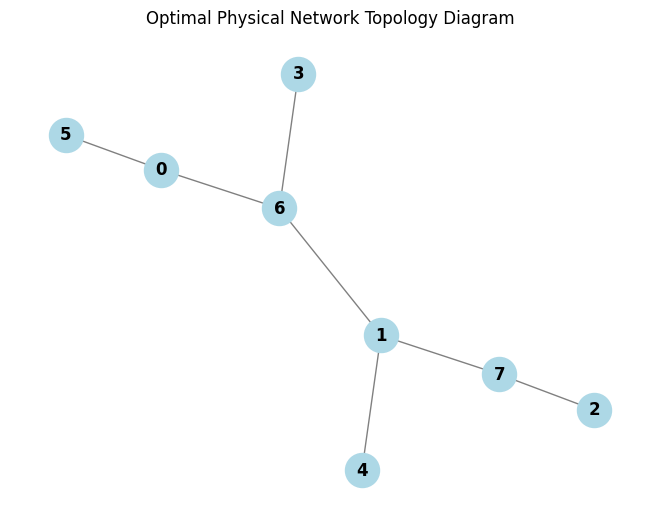

Simulated annealing completed.

Optimal Mapping of Qubits to Nodes:
Qubit 0 -> Node 4
Qubit 1 -> Node 2
Qubit 2 -> Node 7
Qubit 3 -> Node 6
Qubit 4 -> Node 4
Qubit 5 -> Node 6
Qubit 6 -> Node 7
Qubit 7 -> Node 2
Qubit 8 -> Node 3
Qubit 9 -> Node 5
Qubit 10 -> Node 5
Qubit 11 -> Node 3
Qubit 12 -> Node 1
Qubit 13 -> Node 1

Total Communication Cost: 702.4491

Optimal Network Topology:


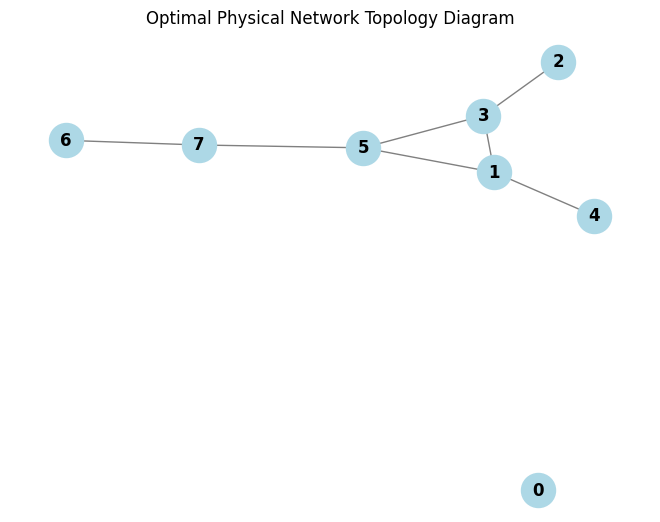

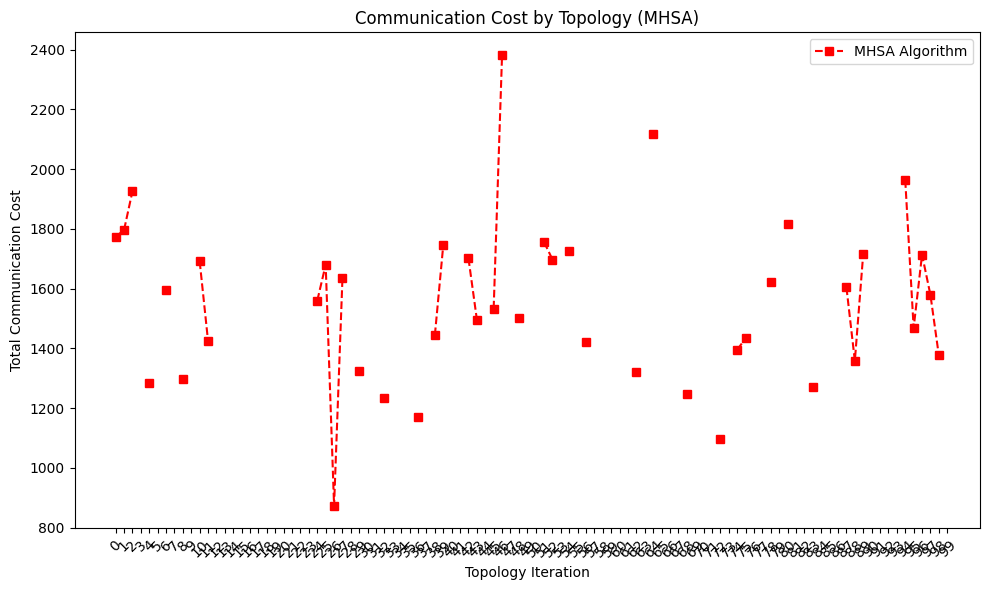

In [ ]:
import random
import math
import networkx as nx
import re
from collections import Counter
import matplotlib.pyplot as plt

# Global parameters

NUM_NODES = 8      # Number of QPU nodes in the network.
NUM_QUBITS = 14    # Number of logical qubits in the quantum circuit.
MAX_EDGES = 7      # Maximum allowed edges in the topology.
PE = 0.99          # Success rate of EPR pair generation.
PS = 0.763         # Success rate of entanglement swapping.
PC = 0.79          # Fidelity of remote CNOT circuit.
nodes_degree = [3 for _ in range(NUM_NODES)]  # Maximum number of edges per node.
# capacity = [2 for _ in range(NUM_NODES)]
# Hyperparameters for DQC-TG(-Plus) algorithm
ALPHA = 0.9        # Cooling parameter for simulated annealing.
N_EQ_LB = 5        # Number of trials for equilibrium test.
N_STUCK = 5        # Conversion point (stuck condition).
N_STAGE = 10       # Number of reheating stages.
N_ITER = 100       # Number of iterations with different initial solutions.


def extract_cnot_operations(qasm_file):
    """
    Extracts CNOT pairs and counts from a given QASM file.
    """
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()
    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]
    return Counter(normalized_pairs)


def random_initial_mapping(capacities):
    """
    Generates a random initial mapping of qubits to nodes based on their capacities.
    """
    available = []
    for node, cap in enumerate(capacities):
        available.extend([node] * cap)
    if len(available) < NUM_QUBITS:
        raise ValueError("Capacity insufficient to map all qubits.")
    random.shuffle(available)
    mapping = available[:NUM_QUBITS]

    network_graph = nx.random_regular_graph(3, NUM_NODES)
    while network_graph.number_of_edges() > MAX_EDGES:
        edge = random.choice(list(network_graph.edges()))
        network_graph.remove_edge(*edge)

    return mapping, network_graph


def node_distance(i, j, network_graph):
    """
    Returns the distance (in hop count) between two nodes i and j
    in the current network topology (network_graph).
    """
    try:
        distance = nx.shortest_path_length(network_graph, source=i, target=j)
    except nx.NetworkXNoPath:
        distance = float('inf')
    return distance


def calculate_cost(mapping, coupled_pairs, network_graph):
    """
    Calculates the total communication cost for a given qubit mapping.
    """
    total_cost = 0.0
    for (q1, q2), cnt in coupled_pairs.items():
        node1 = mapping[q1]
        node2 = mapping[q2]
        if node1 == node2:
            cost = 0
        else:
            d = max(1, node_distance(node1, node2, network_graph))
            denominator = (PE ** d) * (PS ** (d - 1)) * PC
            cost = 1.0 / denominator if denominator != 0 else float('inf')
        total_cost += cost * cnt
    return total_cost


def two_plus_one_move(network_graph):
    """
    Implements the (2+1)-move algorithm as described in Algorithm 1.
    Generates a neighborhood of solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph.

    Parameters:
        network_graph: NetworkX Graph - The current network topology design W.

    Returns:
        neighborhood_solutions: List[NetworkX Graph] - The neighborhood of solutions.
    """
    neighborhood_solutions = []
    edges = list(network_graph.edges())

    # Step 3-10: Conditional pairwise exchange
    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            va, vb = edges[i]
            vc, vd = edges[j]

            # Ensure all nodes are distinct
            if len(set([va, vb, vc, vd])) == 4:
                # Case 1: Replace (va, vb) and (vc, vd) with (va, vc) and (vb, vd)
                if not network_graph.has_edge(va, vc) and not network_graph.has_edge(vb, vd):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vc)
                    new_graph.add_edge(vb, vd)
                    neighborhood_solutions.append(new_graph)

                # Case 2: Replace (va, vb) and (vc, vd) with (va, vd) and (vb, vc)
                if not network_graph.has_edge(va, vd) and not network_graph.has_edge(vb, vc):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.remove_edge(vc, vd)
                    new_graph.add_edge(va, vd)
                    new_graph.add_edge(vb, vc)
                    neighborhood_solutions.append(new_graph)

    # Step 11-16: Single-edge spin move
    for i in range(len(edges)):
        va, vb = edges[i]
        for node in network_graph.nodes():
            # Check if node has idle communication qubits (degree < max degree)
            if node != va and node != vb and network_graph.degree[node] < nodes_degree[node]:
                # Case 3
                # Spin edge (va, vb) to (va, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(va, node)
                neighborhood_solutions.append(new_graph)

                # Spin edge (va, vb) to (vb, node)
                new_graph = network_graph.copy()
                new_graph.remove_edge(va, vb)
                new_graph.add_edge(vb, node)
                neighborhood_solutions.append(new_graph)

    return neighborhood_solutions


def two_plus_one_smove(mapping, coupled_pairs, network_graph, capacities):
    """
    Implements the (2+1)-s-move algorithm as described in Algorithm 2.
    Generates neighborhood solutions by applying conditional pairwise exchanges
    or single-edge spin moves to the current topology graph and adjusts qubit allocation.
    """
    neighborhood_solutions = []

    # Step 1: Generate neighborhood of W using (2+1)-move
    topology_neighborhood = two_plus_one_move(network_graph)

    # Step 2: Add each topology solution with the current mapping into the neighborhood
    for temp_network_graph in topology_neighborhood:
        neighborhood_solutions.append((temp_network_graph, mapping.copy()))

    # Step 3: Adjust mapping to ensure all qubits are allocated properly
    num_qubits = len(mapping)
    num_nodes = len(capacities)
    total_capacity = sum(capacities)

    if num_qubits < total_capacity:
        # Add pseudo logical qubits to fill unused computation capacity
        extended_mapping = mapping + [None] * (total_capacity - num_qubits)
        mapping = extended_mapping

    # Iterate over nodes and ensure capacity constraints are satisfied
    for node in range(num_nodes):
        while sum(1 for q in mapping if q == node) < capacities[node]:
            # Find a pseudo qubit and allocate it to this node
            for i in range(len(mapping)):
                if mapping[i] is None:
                    mapping[i] = node
                    break

    # Step 4: Perform qubit swaps between real logical qubits or pseudo logical qubits
    for i in range(len(mapping)):
        for j in range(i + 1, len(mapping)):
            if mapping[i] != mapping[j]:
                # Generate new mapping by swapping qubits i and j
                new_mapping = mapping.copy()
                new_mapping[i], new_mapping[j] = new_mapping[j], new_mapping[i]

                # Ensure only real logical qubits are swapped back into the original size
                trimmed_mapping = new_mapping[:num_qubits]

                # Add the new solution (network topology + qubit allocation) to the neighborhood
                neighborhood_solutions.append((network_graph.copy(), trimmed_mapping))

    return neighborhood_solutions

def simulated_annealing(coupled_pairs, initial_mapping, initial_network, capacities, t0=10):
    """
    Implements the Simulated Annealing (SA) algorithm with reheating and iterated mechanism.

    Parameters:
        coupled_pairs: Counter - CNOT operations extracted from the quantum circuit.
        initial_mapping: List - Initial mapping of qubits to nodes.
        initial_network: NetworkX Graph - Initial network topology.
        capacities: List - Capacity of each QPU node.
        t0: float - Initial temperature for SA.

    Returns:
        best_mapping: List - Optimal qubit-to-node mapping.
        best_network: NetworkX Graph - Optimal network topology.
        best_cost: float - Minimum communication cost achieved.
    """
    best_mapping = None
    best_network = None
    best_cost = float('inf')
    costs=[]  # Initialize with a very high cost

    # Iterated mechanism: Perform SA for N_ITER iterations with different initial solutions
    for iteration in range(N_ITER):
        # print(f"Iteration {iteration + 1}/{N_ITER}: Starting simulated annealing...")

        # Generate random initial solution for this iteration
        current_mapping, current_network = random_initial_mapping(capacities)
        current_cost = calculate_cost(current_mapping, coupled_pairs, current_network)
        costs.append(current_cost)

        temperature = t0
        stuck_count = 0  # Count how long we've been stuck without improvement

        # Multistage reheating mechanism (N_STAGE stages)
        for stage in range(N_STAGE):
            # print(f"Stage {stage + 1}/{N_STAGE}: Starting with temperature {temperature:.2f}")

            for _ in range(N_EQ_LB):  # Equilibrium test
                # Generate neighborhood solutions using (2+1)-s-move
                neighbors = two_plus_one_smove(current_mapping, coupled_pairs, current_network, capacities)

                for neighbor_network, neighbor_mapping in neighbors:
                    # Calculate cost for the neighbor solution
                    neighbor_cost = calculate_cost(neighbor_mapping, coupled_pairs, neighbor_network)

                    # Determine acceptance probability
                    delta_cost = neighbor_cost - current_cost
                    if delta_cost < 0 or random.random() < math.exp(-delta_cost / temperature):
                        # Accept the neighbor solution
                        current_mapping = neighbor_mapping[:]
                        current_network = neighbor_network.copy()
                        current_cost = neighbor_cost
                        # costs.append(current_cost)

                        # Update best solution if improved
                        if current_cost < best_cost:
                            best_mapping = current_mapping[:]
                            best_network = current_network.copy()
                            best_cost = current_cost
                            stuck_count = 0  # Reset stuck counter after improvement
                        else:
                            stuck_count += 1

                # Check if stuck condition is met
                if stuck_count >= N_STUCK:
                    # print(f"Stuck at local optimum. Switching to local search...")
                    # Perform local search using (2+1)-opt to escape local optima
                    neighbors = two_plus_one_move(current_network)
                    for neighbor in neighbors:
                        temp_cost = calculate_cost(current_mapping, coupled_pairs, neighbor)
                        if temp_cost < current_cost:
                            current_network = neighbor.copy()
                            current_cost = temp_cost
                            # costs.append(current_cost)
                            break

            # Reduce temperature (cooling schedule)
            temperature *= ALPHA

            # Reheat if necessary (multistage reheating mechanism)
            if stage < N_STAGE - 1:
                temperature = t0

            # print(f"Stage {stage + 1} completed. Best cost so far: {best_cost:.4f}")

    print("Simulated annealing completed.")
    return best_mapping, best_network, best_cost,costs

def draw_topology(network_graph):
    """
    Draws the physical network topology diagram using networkx and matplotlib.
    (This diagram shows the original network_graph.)
    """
    pos = nx.spring_layout(network_graph)
    nx.draw(network_graph, pos, with_labels=True, node_color="lightblue",
            edge_color="gray", node_size=600, font_weight="bold")
    plt.title("Optimal Physical Network Topology Diagram")
    plt.show()

# Main function to execute the algorithm
def main(qasm_file):
    """
    Main function to execute the entire DQC-TG framework using Simulated Annealing.

    Parameters:
        qasm_file: str - Path to the QASM file containing the quantum circuit.
    """
    capacities = [2] * NUM_NODES  # Example capacities for each QPU node

    # Extract CNOT operations from QASM file
    coupled_pairs = extract_cnot_operations(qasm_file)

    # Generate initial random mapping and network topology
    initial_mapping, initial_network = random_initial_mapping(capacities)

    print("Initial Mapping:", initial_mapping)
    print("Initial Network Topology:")
    draw_topology(initial_network)

    # Run simulated annealing to optimize topology and mapping
    best_mapping, best_network, best_cost,costs = simulated_annealing(
        coupled_pairs,
        initial_mapping,
        initial_network,
        capacities,
        t0=10  # Initial temperature
    )

    print("\nOptimal Mapping of Qubits to Nodes:")
    for qubit, node in enumerate(best_mapping):
        print(f"Qubit {qubit} -> Node {node}")

    print(f"\nTotal Communication Cost: {best_cost:.4f}")

    print("\nOptimal Network Topology:")
    draw_topology(best_network)
    plt.figure(figsize=(10, 6))
    x = list(range(len(costs)))
    plt.plot(x, costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.xticks(x,x, rotation=45)
    plt.xlabel("Topology Iteration")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Execute main function with a sample QASM file path
if __name__ == "__main__":
    qasm_file_path = "/content/cm42a_207.qasm"  # Replace with your actual file path
    main(qasm_file_path)

with invalid edges

Initial Mapping: [2, 3, 0, 7, 1, 5, 7, 6, 0, 3, 4, 1, 5, 4]
Initial Network Topology:


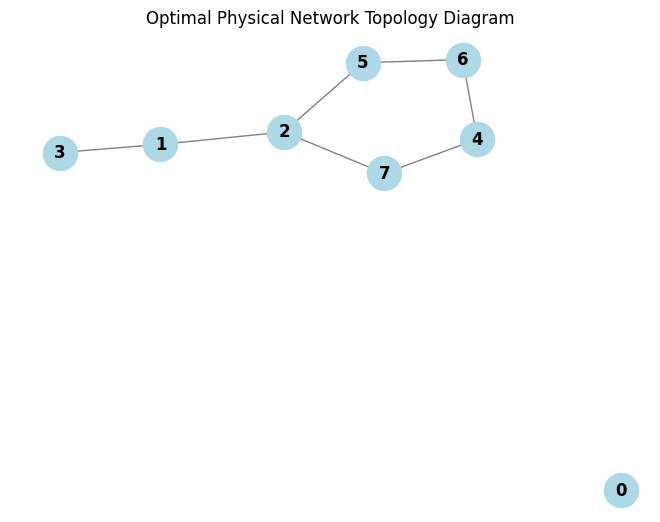

Simulated annealing completed.

Optimal Mapping of Qubits to Nodes:
Qubit 0 -> Node 1
Qubit 1 -> Node 1
Qubit 2 -> Node 4
Qubit 3 -> Node 4
Qubit 4 -> Node 5
Qubit 5 -> Node 5
Qubit 6 -> Node 7
Qubit 7 -> Node 7
Qubit 8 -> Node 2
Qubit 9 -> Node 2
Qubit 10 -> Node 6
Qubit 11 -> Node 6
Qubit 12 -> Node 3
Qubit 13 -> Node 3

Total Communication Cost: 81.8310

Optimal Network Topology:


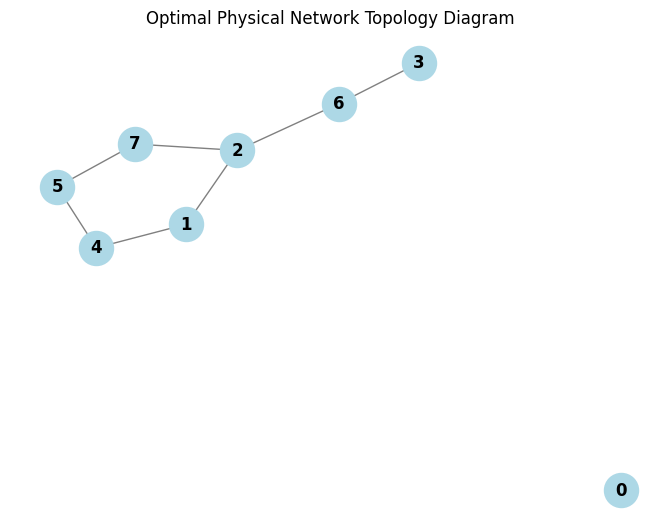

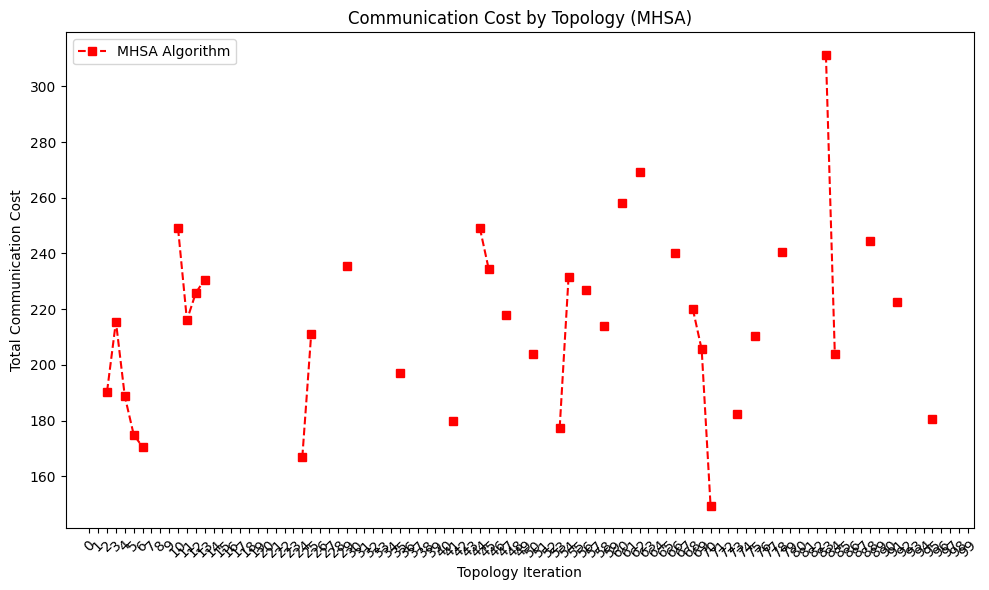

In [ ]:
import random
import math
import networkx as nx
import re
from collections import Counter
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 8
NUM_QUBITS = 14
MAX_EDGES = 7
PE = 0.99
PS = 0.763
PC = 0.79
nodes_degree = [3 for _ in range(NUM_NODES)]
ALPHA = 0.9
N_EQ_LB = 5
N_STUCK = 5
N_STAGE = 10
N_ITER = 100

# Invalid edges to exclude
invalid_edges = [{3, 4}, {0, 6}, {0, 3}]

# Helper function to check if edge is invalid
def is_invalid_edge(u, v):
    return {u, v} in invalid_edges


def extract_cnot_operations(qasm_file):
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()
    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]
    return Counter(normalized_pairs)


def random_initial_mapping(capacities):
    available = []
    for node, cap in enumerate(capacities):
        available.extend([node] * cap)
    if len(available) < NUM_QUBITS:
        raise ValueError("Capacity insufficient to map all qubits.")
    random.shuffle(available)
    mapping = available[:NUM_QUBITS]

    while True:
        network_graph = nx.random_regular_graph(3, NUM_NODES)
        # Remove invalid edges
        to_remove = [(u, v) for u, v in network_graph.edges() if is_invalid_edge(u, v)]
        network_graph.remove_edges_from(to_remove)

        while network_graph.number_of_edges() > MAX_EDGES:
            edge = random.choice(list(network_graph.edges()))
            if is_invalid_edge(edge[0], edge[1]):
                continue
            network_graph.remove_edge(*edge)

        if not any(is_invalid_edge(u, v) for u, v in network_graph.edges()):
            break

    return mapping, network_graph


def node_distance(i, j, network_graph):
    try:
        return nx.shortest_path_length(network_graph, source=i, target=j)
    except nx.NetworkXNoPath:
        return float('inf')


def calculate_cost(mapping, coupled_pairs, network_graph):
    total_cost = 0.0
    for (q1, q2), cnt in coupled_pairs.items():
        node1 = mapping[q1]
        node2 = mapping[q2]
        if node1 == node2:
            cost = 0
        else:
            d = max(1, node_distance(node1, node2, network_graph))
            denominator = (PE ** d) * (PS ** (d - 1)) * PC
            cost = 1.0 / denominator if denominator != 0 else float('inf')
        total_cost += cost * cnt
    return total_cost


def two_plus_one_move(network_graph):
    neighborhood_solutions = []
    edges = list(network_graph.edges())

    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            va, vb = edges[i]
            vc, vd = edges[j]

            if len(set([va, vb, vc, vd])) == 4:
                if not network_graph.has_edge(va, vc) and not network_graph.has_edge(vb, vd):
                    if not is_invalid_edge(va, vc) and not is_invalid_edge(vb, vd):
                        new_graph = network_graph.copy()
                        new_graph.remove_edge(va, vb)
                        new_graph.remove_edge(vc, vd)
                        new_graph.add_edge(va, vc)
                        new_graph.add_edge(vb, vd)
                        neighborhood_solutions.append(new_graph)

                if not network_graph.has_edge(va, vd) and not network_graph.has_edge(vb, vc):
                    if not is_invalid_edge(va, vd) and not is_invalid_edge(vb, vc):
                        new_graph = network_graph.copy()
                        new_graph.remove_edge(va, vb)
                        new_graph.remove_edge(vc, vd)
                        new_graph.add_edge(va, vd)
                        new_graph.add_edge(vb, vc)
                        neighborhood_solutions.append(new_graph)

    for i in range(len(edges)):
        va, vb = edges[i]
        for node in network_graph.nodes():
            if node != va and node != vb and network_graph.degree[node] < nodes_degree[node]:
                if not network_graph.has_edge(va, node) and not is_invalid_edge(va, node):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.add_edge(va, node)
                    neighborhood_solutions.append(new_graph)

                if not network_graph.has_edge(vb, node) and not is_invalid_edge(vb, node):
                    new_graph = network_graph.copy()
                    new_graph.remove_edge(va, vb)
                    new_graph.add_edge(vb, node)
                    neighborhood_solutions.append(new_graph)

    return neighborhood_solutions


def two_plus_one_smove(mapping, coupled_pairs, network_graph, capacities):
    neighborhood_solutions = []
    topology_neighborhood = two_plus_one_move(network_graph)

    for temp_network_graph in topology_neighborhood:
        neighborhood_solutions.append((temp_network_graph, mapping.copy()))

    num_qubits = len(mapping)
    num_nodes = len(capacities)
    total_capacity = sum(capacities)

    if num_qubits < total_capacity:
        extended_mapping = mapping + [None] * (total_capacity - num_qubits)
        mapping = extended_mapping

    for node in range(num_nodes):
        while sum(1 for q in mapping if q == node) < capacities[node]:
            for i in range(len(mapping)):
                if mapping[i] is None:
                    mapping[i] = node
                    break

    for i in range(len(mapping)):
        for j in range(i + 1, len(mapping)):
            if mapping[i] != mapping[j]:
                new_mapping = mapping.copy()
                new_mapping[i], new_mapping[j] = new_mapping[j], new_mapping[i]
                trimmed_mapping = new_mapping[:num_qubits]
                neighborhood_solutions.append((network_graph.copy(), trimmed_mapping))

    return neighborhood_solutions


def simulated_annealing(coupled_pairs, initial_mapping, initial_network, capacities, t0=10):
    best_mapping = None
    best_network = None
    best_cost = float('inf')
    costs = []

    for iteration in range(N_ITER):
        current_mapping, current_network = random_initial_mapping(capacities)
        current_cost = calculate_cost(current_mapping, coupled_pairs, current_network)
        costs.append(current_cost)
        temperature = t0
        stuck_count = 0

        for stage in range(N_STAGE):
            for _ in range(N_EQ_LB):
                neighbors = two_plus_one_smove(current_mapping, coupled_pairs, current_network, capacities)

                for neighbor_network, neighbor_mapping in neighbors:
                    neighbor_cost = calculate_cost(neighbor_mapping, coupled_pairs, neighbor_network)
                    delta_cost = neighbor_cost - current_cost

                    if delta_cost < 0 or random.random() < math.exp(-delta_cost / temperature):
                        current_mapping = neighbor_mapping[:]
                        current_network = neighbor_network.copy()
                        current_cost = neighbor_cost

                        if current_cost < best_cost:
                            best_mapping = current_mapping[:]
                            best_network = current_network.copy()
                            best_cost = current_cost
                            stuck_count = 0
                        else:
                            stuck_count += 1

                if stuck_count >= N_STUCK:
                    neighbors = two_plus_one_move(current_network)
                    for neighbor in neighbors:
                        temp_cost = calculate_cost(current_mapping, coupled_pairs, neighbor)
                        if temp_cost < current_cost:
                            current_network = neighbor.copy()
                            current_cost = temp_cost
                            break

            temperature *= ALPHA
            if stage < N_STAGE - 1:
                temperature = t0

    print("Simulated annealing completed.")
    return best_mapping, best_network, best_cost, costs


def draw_topology(network_graph):
    pos = nx.spring_layout(network_graph)
    nx.draw(network_graph, pos, with_labels=True, node_color="lightblue",
            edge_color="gray", node_size=600, font_weight="bold")
    plt.title("Optimal Physical Network Topology Diagram")
    plt.show()


def main(qasm_file):
    capacities = [2] * NUM_NODES
    coupled_pairs = extract_cnot_operations(qasm_file)
    initial_mapping, initial_network = random_initial_mapping(capacities)

    print("Initial Mapping:", initial_mapping)
    print("Initial Network Topology:")
    draw_topology(initial_network)

    best_mapping, best_network, best_cost, costs = simulated_annealing(
        coupled_pairs, initial_mapping, initial_network, capacities, t0=10
    )

    print("\nOptimal Mapping of Qubits to Nodes:")
    for qubit, node in enumerate(best_mapping):
        print(f"Qubit {qubit} -> Node {node}")

    print(f"\nTotal Communication Cost: {best_cost:.4f}")
    print("\nOptimal Network Topology:")
    draw_topology(best_network)

    plt.figure(figsize=(10, 6))
    x = list(range(len(costs)))
    plt.plot(x, costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.xticks(x, x, rotation=45)
    plt.xlabel("Topology Iteration")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    qasm_file_path = "/content/0410184_169.qasm"  # Replace with your QASM path
    main(qasm_file_path)
